In [3]:
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import Data
import os

# Пути
PATH_RAW = '../dataset/home-credit-default-risk/'
PATH_PROCESSED = '../dataset/processed/'

# Загружаем основную таблицу
app_train = pd.read_csv(PATH_RAW + 'application_train.csv')
print(f"application_train: {app_train.shape}")

# Загружаем bureau и previous_application
bureau = pd.read_csv(PATH_RAW + 'bureau.csv')
prev_app = pd.read_csv(PATH_RAW + 'previous_application.csv')

print(f"bureau: {bureau.shape}")
print(f"previous_application: {prev_app.shape}")

application_train: (307511, 122)
bureau: (1716428, 17)
previous_application: (1670214, 37)


In [8]:
np.random.seed(42)
all_clients = set(app_train['SK_ID_CURR'])
sampled_clients = set(np.random.choice(list(all_clients), size=50000, replace=False))
print(f"Выбрано клиентов: {len(sampled_clients)}")

Выбрано клиентов: 50000


In [9]:
df_selected = app_train[app_train['SK_ID_CURR'].isin(sampled_clients)].copy()
df_selected = df_selected.set_index('SK_ID_CURR').sort_index()

y = torch.tensor(df_selected['TARGET'].values, dtype=torch.long)

features_df = df_selected.drop('TARGET', axis=1)
numeric_cols = features_df.select_dtypes(include=[np.number]).columns
X = torch.tensor(features_df[numeric_cols].fillna(0).values, dtype=torch.float)
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: torch.Size([50000, 104]), y shape: torch.Size([50000])


In [10]:
from sklearn.preprocessing import StandardScaler

# Переводим тензор X в numpy
X_np = X.numpy()

# Масштабируем (среднее 0, std 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_np)

print(f"Форма масштабированных признаков: {X_scaled.shape}")
print(f"Среднее (первые 5): {X_scaled.mean(axis=0)[:5].round(4)}")
print(f"Стд.откл. (первые 5): {X_scaled.std(axis=0)[:5].round(4)}")

Форма масштабированных признаков: (50000, 104)
Среднее (первые 5): [-0. -0.  0. -0. -0.]
Стд.откл. (первые 5): [1. 1. 1. 1. 1.]


In [11]:
from sklearn.neighbors import NearestNeighbors

k = 10  # число соседей

print(f"Построение {k}-NN графа...")
nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree', n_jobs=-1)
nbrs.fit(X_scaled)

distances, indices = nbrs.kneighbors(X_scaled)

# Формируем список рёбер (исключая петли i==j)
edge_list = []
for i in range(indices.shape[0]):
    for j in indices[i]:
        if i != j:
            edge_list.append([i, j])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

print(f"Количество рёбер: {edge_index.shape[1]}")
print(f"Пример первых 5 рёбер (столбцы):\n{edge_index[:, :5]}")

Построение 10-NN графа...
Количество рёбер: 500000
Пример первых 5 рёбер (столбцы):
tensor([[    0,     0,     0,     0,     0],
        [31691, 26989, 26366, 15408, 45212]])


In [12]:
# Делаем граф неориентированным: добавляем обратные рёбра
edge_list_rev = [[j, i] for i, j in edge_list]  # создаём обратные
edge_list_all = edge_list + edge_list_rev
edge_index = torch.tensor(edge_list_all, dtype=torch.long).t().contiguous()
print(f"Количество рёбер после симметризации: {edge_index.shape[1]}")

Количество рёбер после симметризации: 1000000


In [13]:
data = Data(x=X, edge_index=edge_index, y=y)

print("\n" + "="*55)
print("Информация о построенном графе (HCDR k-NN):")
print(data)
print(f"  Узлов:               {data.num_nodes}")
print(f"  Рёбер:               {data.num_edges}")
print(f"  Средняя степень:     {data.num_edges / data.num_nodes:.2f}")
print(f"  Признаков на узел:   {data.num_node_features}")
print(f"  Доля дефолтов (y=1): {data.y.sum().item() / len(data.y) * 100:.2f}%")


Информация о построенном графе (HCDR k-NN):
Data(x=[50000, 104], edge_index=[2, 1000000], y=[50000])
  Узлов:               50000
  Рёбер:               1000000
  Средняя степень:     20.00
  Признаков на узел:   104
  Доля дефолтов (y=1): 8.05%


In [14]:
import os
os.makedirs(PATH_PROCESSED, exist_ok=True)
torch.save(data, PATH_PROCESSED + 'hcdr_knn_graph.pt')
print(f"\n✅ Граф сохранён в '{PATH_PROCESSED}hcdr_knn_graph.pt'")


✅ Граф сохранён в '../dataset/processed/hcdr_knn_graph.pt'


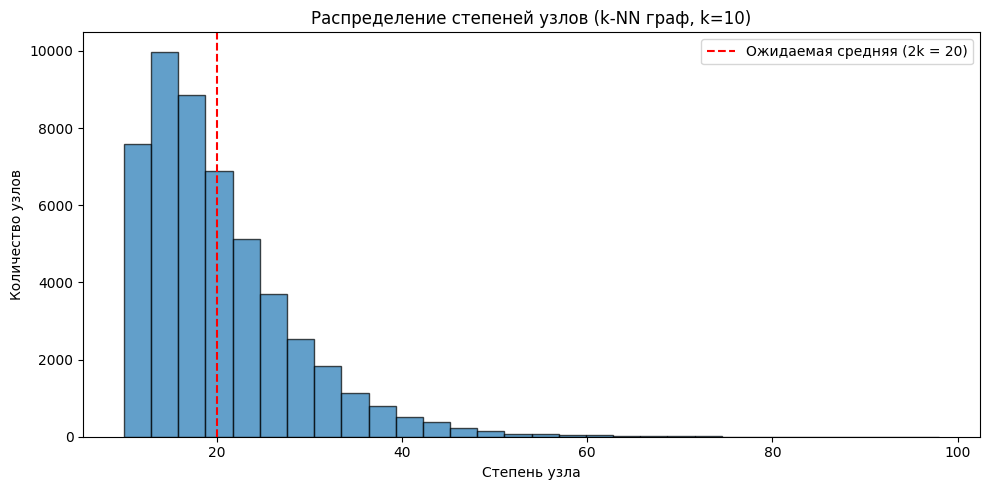

In [15]:
import matplotlib.pyplot as plt

# Подсчёт степеней узлов (сколько рёбер у каждого)
degrees = np.bincount(edge_index[0].numpy(), minlength=data.num_nodes)

plt.figure(figsize=(10, 5))
plt.hist(degrees, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Степень узла')
plt.ylabel('Количество узлов')
plt.title(f'Распределение степеней узлов (k-NN граф, k={k})')
plt.axvline(x=k*2, color='red', linestyle='--', label=f'Ожидаемая средняя (2k = {k*2})')
plt.legend()
plt.tight_layout()

# Убедимся, что папка results существует
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/degree_distribution_hcdr.png', dpi=150)
plt.show()

## Пороговый граф по косинусному сходству (числовые признаки)

In [2]:
# build_alt_graphs.py (часть 1)
import pandas as pd, numpy as np, torch
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data

# Загружаем и готовим X, y, sampled_clients (как раньше)
# ... (код из ячеек 1-4 вашего ноутбука)
# Предположим, что у нас уже есть X_np (не масштабированные), y, sampled_clients.
# Загружаем снова для чистоты:
PATH_RAW = '../dataset/home-credit-default-risk/'
PATH_PROCESSED = '../dataset/processed/'
app_train = pd.read_csv(PATH_RAW + 'application_train.csv')
np.random.seed(42)
all_clients = set(app_train['SK_ID_CURR'])
sampled_clients = set(np.random.choice(list(all_clients), size=50000, replace=False))
df_sel = app_train[app_train['SK_ID_CURR'].isin(sampled_clients)].set_index('SK_ID_CURR').sort_index()
y = torch.tensor(df_sel['TARGET'].values, dtype=torch.long)
num_cols = df_sel.drop('TARGET', axis=1).select_dtypes(include=[np.number]).columns
X = df_sel[num_cols].fillna(0).values.astype(np.float32)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# k-NN с k=50
k = 50
nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine', algorithm='brute', n_jobs=-1)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
# distances — косинусное расстояние (1 - cos_sim), indices — индексы соседей

threshold = 0.8  # косинусное сходство
edge_list = []
for i in range(len(indices)):
    for j_idx, d in zip(indices[i], distances[i]):
        if i != j_idx:
            cos_sim = 1 - d
            if cos_sim > threshold:
                edge_list.append([i, j_idx])
# симметризуем
edge_set = set()
for u, v in edge_list:
    edge_set.add((u, v))
    edge_set.add((v, u))
edge_index = torch.tensor(list(edge_set), dtype=torch.long).t().contiguous()
data_cos = Data(x=torch.tensor(X_scaled, dtype=torch.float), edge_index=edge_index, y=y)
torch.save(data_cos, PATH_PROCESSED + 'hcdr_cos_graph.pt')
print(f"Граф по косинусному сходству: {data_cos}")

Граф по косинусному сходству: Data(x=[50000, 104], edge_index=[2, 1494170], y=[50000])


## Граф на основе общих категориальных признаков

In [3]:
# build_alt_graphs.py (часть 2)
cat_cols = ['CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']
df_cat = df_sel[cat_cols].fillna('Unknown')
# Создаём ключ группы
df_cat['group'] = df_cat[cat_cols].apply(lambda row: '_'.join(row.values.astype(str)), axis=1)
group_to_nodes = df_cat.groupby('group').groups  # словарь: group -> Index узлов
edge_list = []
for nodes in group_to_nodes.values():
    nodes = list(nodes)
    if len(nodes) > 1:
        for i in range(len(nodes)):
            for j in range(i+1, len(nodes)):
                edge_list.append([nodes[i], nodes[j]])
# симметризуем
edge_set = set()
for u, v in edge_list:
    edge_set.add((u, v))
    edge_set.add((v, u))
edge_index = torch.tensor(list(edge_set), dtype=torch.long).t().contiguous()
data_cat = Data(x=torch.tensor(X_scaled, dtype=torch.float), edge_index=edge_index, y=y)
torch.save(data_cat, PATH_PROCESSED + 'hcdr_cat_graph.pt')
print(f"Граф по категориальным признакам: {data_cat}")

Граф по категориальным признакам: Data(x=[50000, 104], edge_index=[2, 127116768], y=[50000])
